In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from matplotlib.ticker import ScalarFormatter

In [3]:
import sys, types
import numpy.core.numeric as _nc
_np_core = types.ModuleType("numpy._core")
_np_core.numeric = types.ModuleType("numpy._core.numeric")
_np_core.numeric.__dict__.update(_nc.__dict__)
sys.modules["numpy._core"] = _np_core
sys.modules["numpy._core.numeric"] = _np_core.numeric

# SCP Method

In [4]:
base_path   = r"C:\Users\MGA5500\Desktop\PROJECT\WW\Data"
calib_seeds = list(range(60, 69))
test_seed   = 69
timesteps   = [25, 160]
nx          = 250
alpha       = 0.10
slices      = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}

t=25  thresholds: {'u': 0.002695775947723078, 'h': 0.022099281171875873, 'r': 0.0016078121395009005}


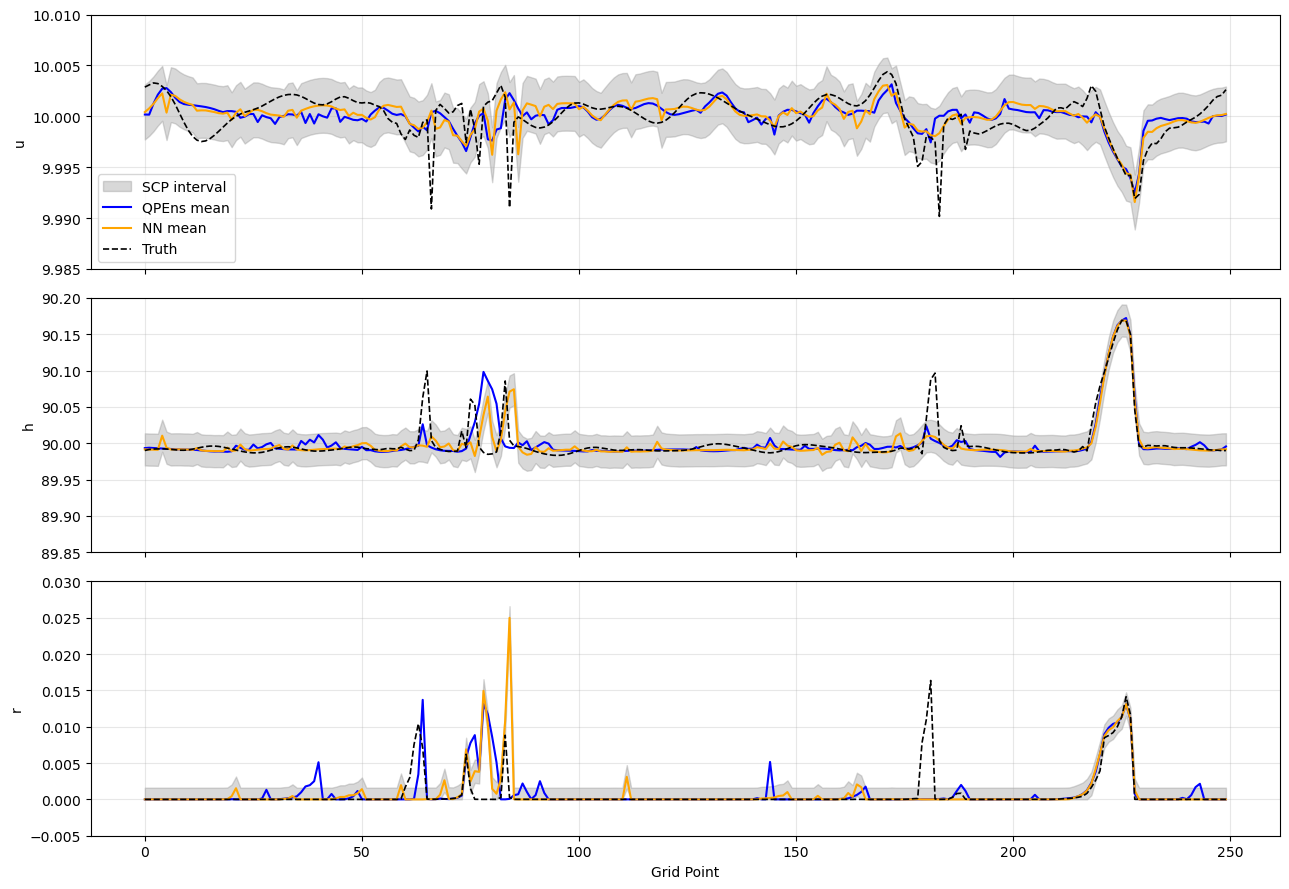

t=160  thresholds: {'u': 0.00256147291328368, 'h': 0.02286199762922081, 'r': 0.002189393093478046}


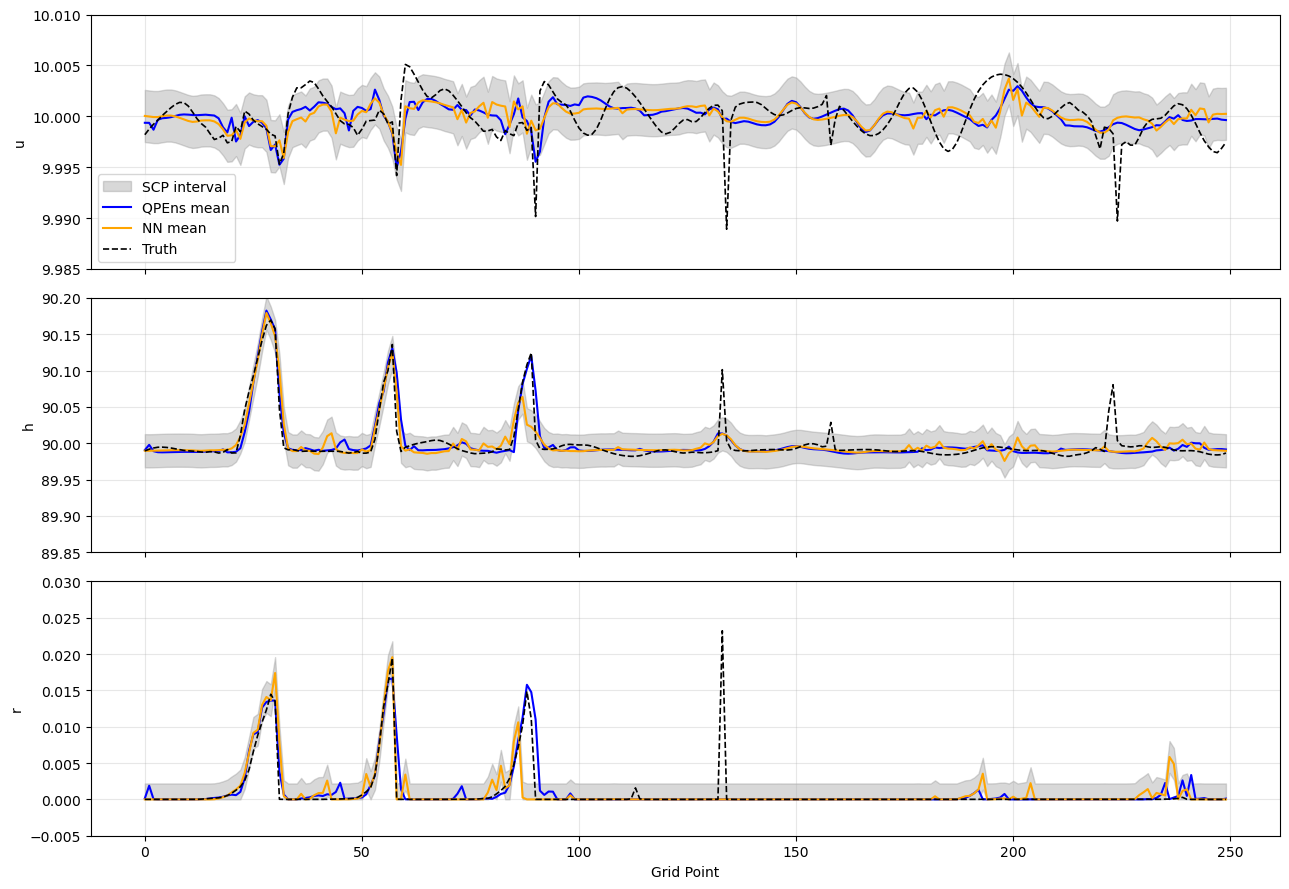

In [5]:
def load_ensemble(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])    
    qpens_arr = np.asarray(qpens['analysis'][t])
    nn_ens    = {v: nn_arr[sl, :]    for v, sl in slices.items()}
    qpens_ens = {v: qpens_arr[sl, :] for v, sl in slices.items()}
    return nn_ens, qpens_ens


def load_means_and_truth(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)
    nn_arr    = np.asarray(nn['analysis'][t])
    qpens_arr = np.asarray(qpens['analysis'][t])
    truth_arr = np.asarray(truth[t])
    nn_mean    = {v: nn_arr[sl, :].mean(axis=1)    for v, sl in slices.items()}
    qpens_mean = {v: qpens_arr[sl, :].mean(axis=1) for v, sl in slices.items()}
    truth_d = {v: truth_arr[sl] for v, sl in slices.items()}
    return nn_mean, qpens_mean, truth_d

def compute_scp_threshold(t):
    nn_cal, qp_cal = {v: [] for v in slices}, {v: [] for v in slices}
    for seed in calib_seeds:
        try:
            nn_ens, qpens_ens = load_ensemble(seed, t)
            for v in slices:
                nn_cal[v].append(nn_ens[v])
                qp_cal[v].append(qpens_ens[v])
        except Exception as e:
            print(f"seed={seed}, t={t}: {e}")
    thresholds = {}
    for v in slices:
        if not nn_cal[v]:
            thresholds[v] = np.nan
            continue
        nn_stack    = np.stack(nn_cal[v], axis=0) 
        qpens_stack = np.stack(qp_cal[v], axis=0)
        scores = np.abs(qpens_stack - nn_stack).ravel()
        N      = scores.size
        qprob  = float(np.ceil((N + 1) * (1 - alpha)) / N)
        thresholds[v] = float(np.quantile(scores, qprob, method="inverted_cdf"))
    return thresholds

YLIMS = {'u': (9.985, 10.010), 'h': (89.85, 90.20), 'r': (-0.005, 0.030)}
YSTEP = {'u': 0.005, 'h': 0.05, 'r': 0.005}

def plot_scp_snapshot(t, thresholds, seed):
    nn_mean, qpens_mean, truth_d = load_means_and_truth(seed, t)
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for ax, v in zip(axes, slices):
        nn_line    = np.asarray(nn_mean[v])
        qpens_line = np.asarray(qpens_mean[v])
        truth_line = np.asarray(truth_d[v])
        x = np.arange(nn_line.size)
        qv = thresholds.get(v, np.nan)
        if np.isfinite(qv):
            lower = np.maximum(nn_line - qv, 0)
            upper = np.maximum(nn_line + qv, 0)
            ax.fill_between(x, lower, upper, alpha=0.3, color='gray', label='SCP interval')
        ax.plot(x, qpens_line, color='blue',   linewidth=1.5, label='QPEns mean')
        ax.plot(x, nn_line,    color='orange',  linewidth=1.5, label='NN mean')
        ax.plot(x, truth_line, color='black', linestyle='--', linewidth=1.2, label='Truth')
        ax.set_ylabel(v)
        ax.grid(True, alpha=0.3)
        if v in YLIMS:
            ax.set_ylim(YLIMS[v])
            ax.set_yticks(np.arange(YLIMS[v][0], YLIMS[v][1] + YSTEP[v]*0.5, YSTEP[v]))
        if v == 'u':
            ax.legend(loc='lower left', frameon=True)
    axes[-1].set_xlabel("Grid Point")
    fig.tight_layout()
    plt.show()
    
for t in timesteps:
    thresh = compute_scp_threshold(t)
    print(f"t={t}  thresholds: {thresh}")
    plot_scp_snapshot(t, thresh, test_seed)

# NCP Method

In [8]:
base_path      = r"C:\Users\MGA5500\Desktop\PROJECT\WW\Data"
calib_seeds    = list(range(60, 69))
test_seed      = 69
rf_train_seeds = list(range(70, 75))
timesteps      = [25, 160]
nx             = 250
alpha          = 0.10
T              = 201
exp_seed       = 1
slices = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}

RF trained for u: n_samples=200000, train_MAE=0.000137
RF trained for h: n_samples=200000, train_MAE=0.000539
RF trained for r: n_samples=200000, train_MAE=0.000027
t=25  thresholds: {'u': 1.334985407644903, 'h': 1.3205859443404042, 'r': 0.0016078121395009005}


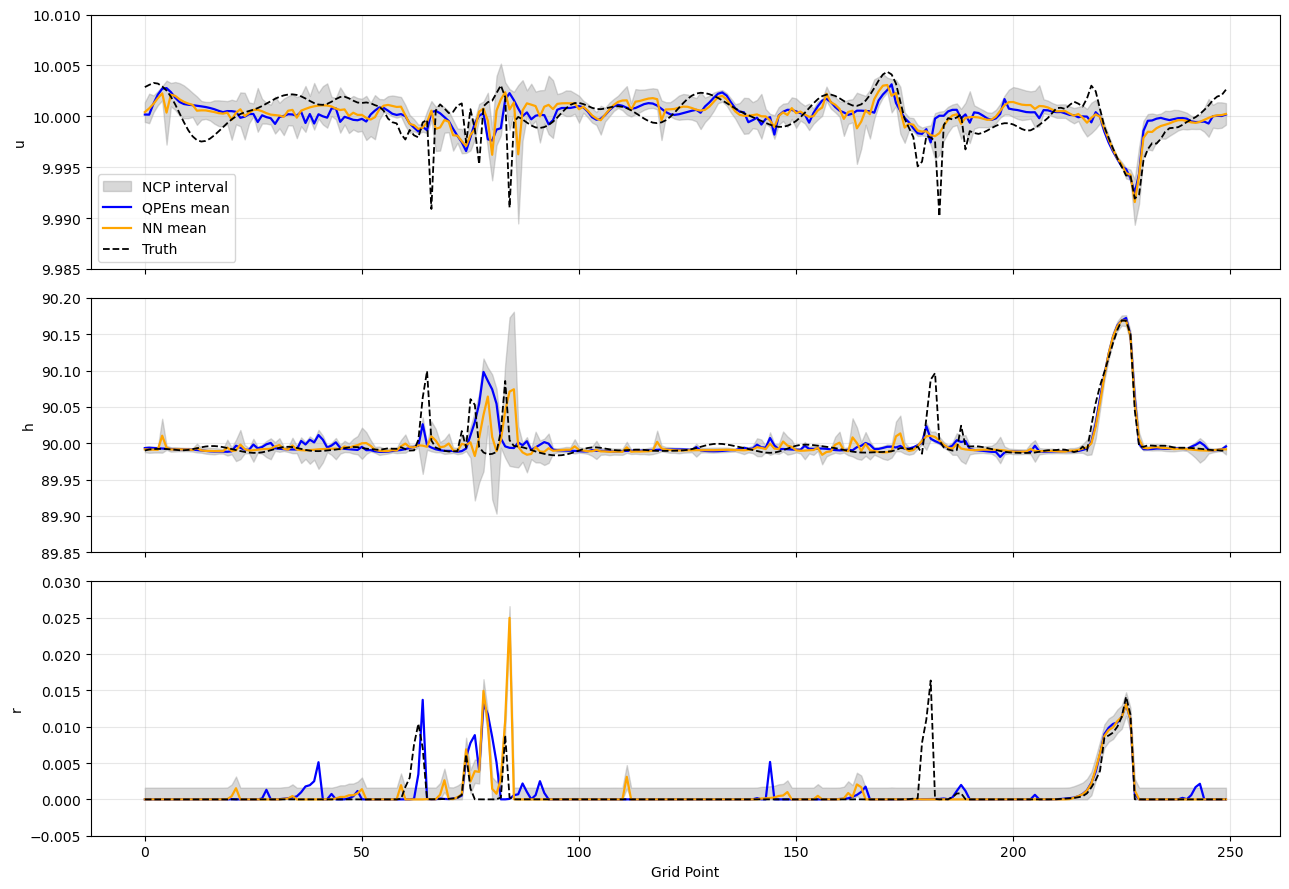

t=160  thresholds: {'u': 1.3333033415440938, 'h': 1.3012421262740517, 'r': 0.002189393093478046}


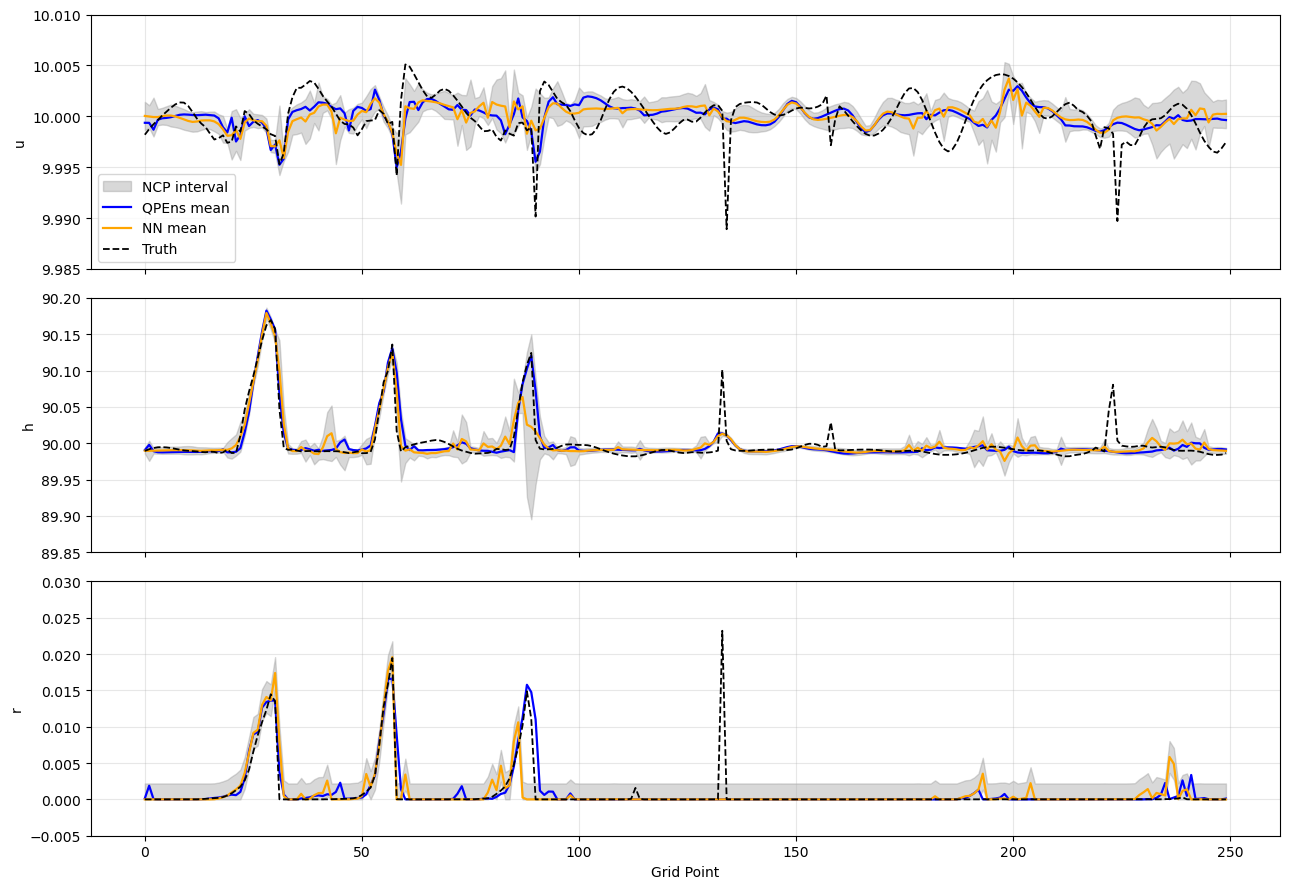

In [9]:
def load_ensemble_ncp(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    arr_nn    = np.asarray(nn['analysis'][t])
    arr_qpens = np.asarray(qpens['analysis'][t])
    nn_ens = {v: arr_nn[sl, :].T    for v, sl in slices.items()}
    q_ens  = {v: arr_qpens[sl, :].T for v, sl in slices.items()}
    return nn_ens, q_ens


def load_means_and_truth_ncp(seed, t):
    path = os.path.join(base_path, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)
    arr_nn    = np.asarray(nn['analysis'][t])
    arr_qpens = np.asarray(qpens['analysis'][t])
    truth_arr = np.asarray(truth[t])
    nn_mean    = {v: arr_nn[sl, :].mean(axis=1)    for v, sl in slices.items()}
    qpens_mean = {v: arr_qpens[sl, :].mean(axis=1) for v, sl in slices.items()}
    truth_d = {v: truth_arr[sl] for v, sl in slices.items()}
    return nn_mean, qpens_mean, truth_d

rf_models   = {}
max_samples = 200_000

for v in slices:
    X_list, y_list = [], []
    for seed in rf_train_seeds:
        for t in range(T):
            try:
                nn_ens, q_ens = load_ensemble_ncp(seed, t)
            except Exception:
                continue
            nn_v = nn_ens[v]
            q_v  = q_ens[v]
            res  = np.abs(q_v - nn_v)
            feat = np.stack([nn_v, q_v], axis=-1)
            X_list.append(feat.reshape(-1, 2))
            y_list.append(res.reshape(-1))

    if not X_list:
        rf_models[v] = None
        continue

    X_all = np.concatenate(X_list)
    y_all = np.concatenate(y_list)

    if len(y_all) > max_samples:
        rng = np.random.default_rng(exp_seed + 123)
        idx = rng.choice(len(y_all), size=max_samples, replace=False)
        X_all, y_all = X_all[idx], y_all[idx]

    rf = RandomForestRegressor(n_estimators=100, max_depth=20,
                               random_state=exp_seed, n_jobs=1)
    rf.fit(X_all, y_all)
    rf_models[v] = rf
    print(f"RF trained for {v}: n_samples={len(y_all)}, "
          f"train_MAE={mean_absolute_error(y_all, rf.predict(X_all)):.6f}")
    
def compute_ncp_threshold(t):
    nn_cal, qp_cal = {v: [] for v in slices}, {v: [] for v in slices}
    for seed in calib_seeds:
        try:
            nn_ens, q_ens = load_ensemble_ncp(seed, t)
            for v in slices:
                nn_cal[v].append(nn_ens[v])
                qp_cal[v].append(q_ens[v])
        except Exception as e:
            print(f"seed={seed}, t={t}: {e}")

    thresholds = {}
    for v in slices:
        if not nn_cal[v]:
            thresholds[v] = np.nan
            continue
        nn_stack = np.stack(nn_cal[v], axis=0)
        qp_stack = np.stack(qp_cal[v], axis=0)
        res_cal  = np.abs(qp_stack - nn_stack)

        if v in ('u', 'h') and rf_models.get(v) is not None:
            feat  = np.stack([nn_stack, qp_stack], axis=-1)
            sigma = rf_models[v].predict(feat.reshape(-1, 2)).reshape(nn_stack.shape)
            scores = res_cal / sigma
        else:
            scores = res_cal

        scores = scores[np.isfinite(scores)]
        N      = scores.size
        qprob  = float(np.ceil((N + 1) * (1 - alpha)) / N)
        thresholds[v] = float(np.quantile(scores.ravel(), qprob, method="inverted_cdf"))
    return thresholds

YLIMS_NCP = {'u': (9.985, 10.010), 'h': (89.85, 90.20), 'r': (-0.005, 0.030)}
YSTEP_NCP = {'u': 0.005, 'h': 0.05, 'r': 0.005}

def plot_ncp_snapshot(t, thresholds, seed):
    nn_mean, qpens_mean, truth_d = load_means_and_truth_ncp(seed, t)
    nn_ens, q_ens = load_ensemble_ncp(seed, t)
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for ax, v in zip(axes, slices):
        nn_line    = np.asarray(nn_mean[v])
        qpens_line = np.asarray(qpens_mean[v])
        truth_line = np.asarray(truth_d[v])
        x  = np.arange(nn_line.size)
        qv = thresholds.get(v, np.nan)
        if np.isfinite(qv):
            if v in ('u', 'h') and rf_models.get(v) is not None:
                nn_t  = nn_ens[v]
                q_t   = q_ens[v]
                feat  = np.stack([nn_t, q_t], axis=-1)
                sigma = rf_models[v].predict(feat.reshape(-1, 2)).reshape(nn_t.shape)
                band  = qv * sigma.mean(axis=0)
            else:
                band = np.full_like(nn_line, qv)
            lower = np.maximum(nn_line - band, 0)
            upper = np.maximum(nn_line + band, 0)
            ax.fill_between(x, lower, upper, alpha=0.3, color='grey', label='NCP interval')
        ax.plot(x, qpens_line, color='blue',   linewidth=1.6, label='QPEns mean')
        ax.plot(x, nn_line,    color='orange',  linewidth=1.6, label='NN mean')
        ax.plot(x, truth_line, color='black', linestyle='--', linewidth=1.3, label='Truth')
        ax.set_ylabel(v)
        ax.grid(True, alpha=0.3)
        if v in YLIMS_NCP:
            ax.set_ylim(YLIMS_NCP[v])
            ax.set_yticks(np.arange(YLIMS_NCP[v][0], YLIMS_NCP[v][1] + YSTEP_NCP[v]*0.5, YSTEP_NCP[v]))
        if v == 'u':
            ax.legend(loc='lower left', frameon=True)
            fmt = ScalarFormatter(useOffset=False)
            fmt.set_scientific(False)
            ax.yaxis.set_major_formatter(fmt)
    axes[-1].set_xlabel("Grid Point")
    fig.tight_layout()
    plt.show()
    
for t in timesteps:
    thresh = compute_ncp_threshold(t)
    print(f"t={t}  thresholds: {thresh}")
    plot_ncp_snapshot(t, thresh, test_seed)    

# CQR Method

In [6]:
base_path_cqr = r"C:\Users\MGA5500\Desktop\PROJECT\WW\MSW codes Reimp"
calib_seeds   = list(range(60, 69))
test_seed     = 69
timesteps     = [25, 160]
nx            = 250
alpha         = 0.10
tau_lo        = alpha / 2.0
tau_hi        = 1.0 - alpha / 2.0
slices = {'u': slice(0, nx), 'h': slice(nx, 2*nx), 'r': slice(2*nx, 3*nx)}
VARS   = ['u', 'h', 'r']

t=25  thresholds: {'u': 0.001865615490965311, 'h': 0.008869235342359616, 'r': 0.00031305027198892703}


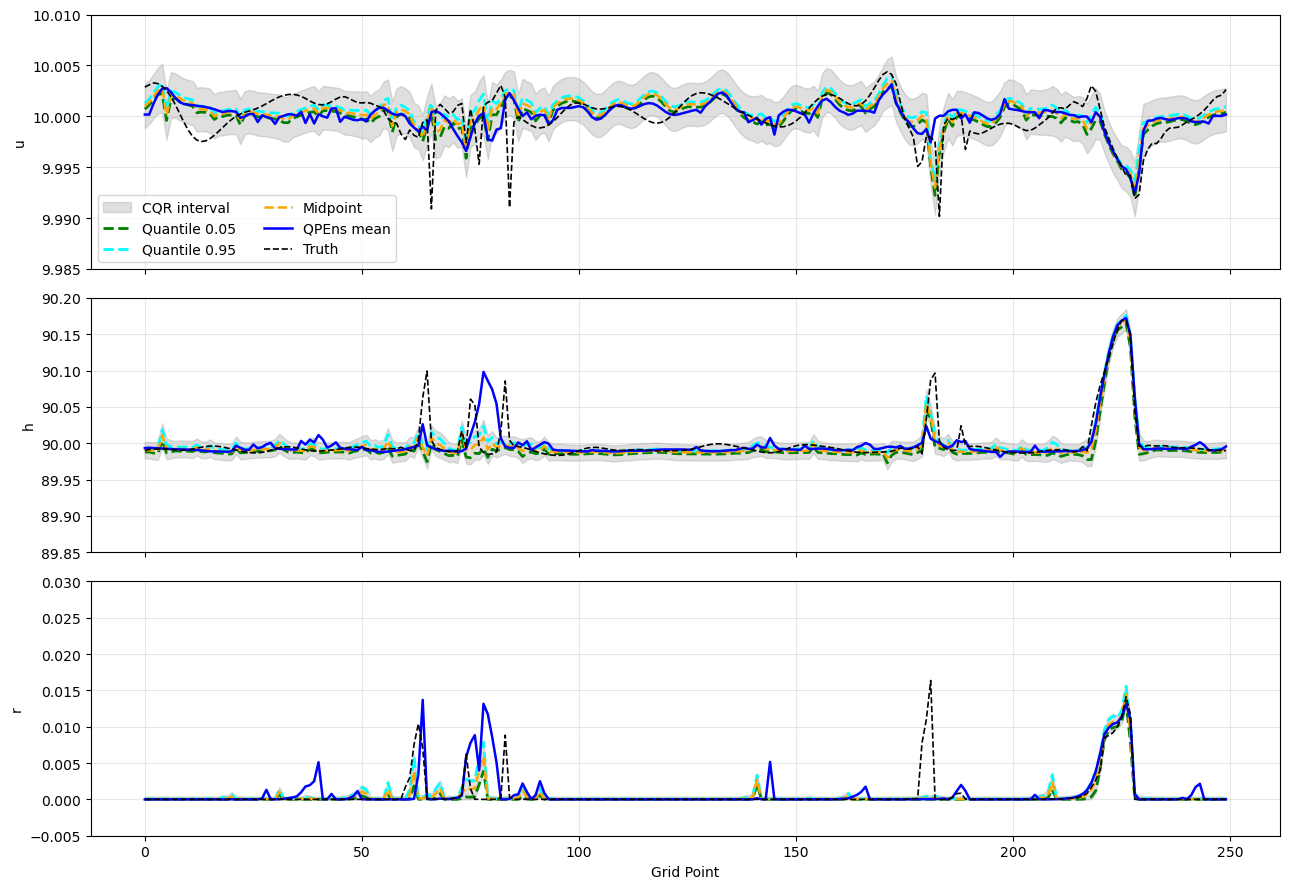

t=160  thresholds: {'u': 0.0018951538861635697, 'h': 0.011991072148319404, 'r': 0.0006295646027979484}


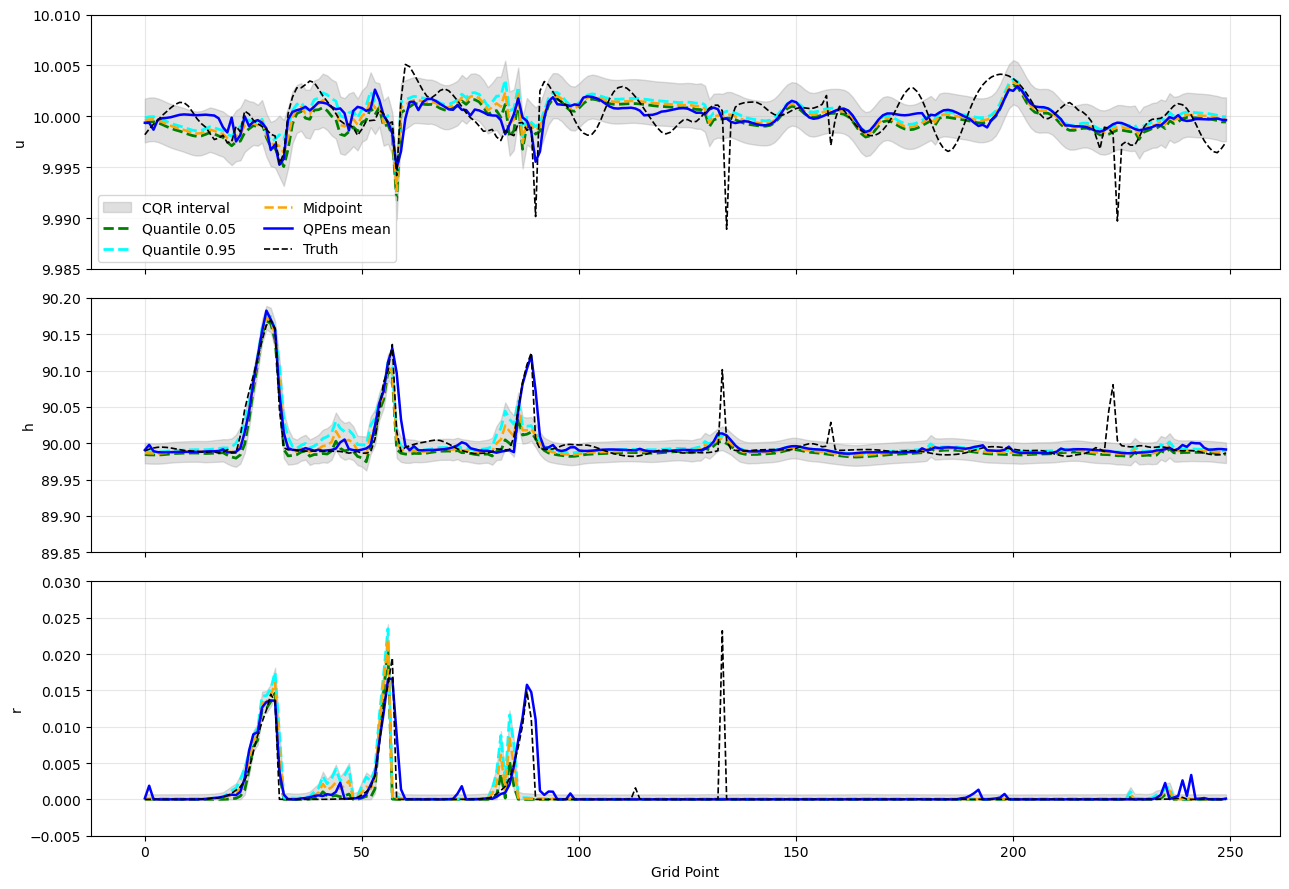

In [7]:
def load_cqr_data(seed, t):
    path = os.path.join(base_path_cqr, str(seed))
    with open(os.path.join(path, 'NN_data.pkl'), 'rb') as f:
        nn = pickle.load(f)
    with open(os.path.join(path, 'QPEns_data.pkl'), 'rb') as f:
        qpens = pickle.load(f)
    with open(os.path.join(path, 'truth_data.pkl'), 'rb') as f:
        truth = pickle.load(f)

    lo_all    = np.asarray(nn['lower'][t])          
    hi_all    = np.asarray(nn['upper'][t])           
    qpens_arr = np.asarray(qpens['analysis'][t])     
    truth_arr = np.asarray(truth[t])
    if truth_arr.ndim == 2:
        truth_arr = truth_arr.mean(axis=1)           

    nn_mid = 0.5 * (lo_all + hi_all)               
    return lo_all, hi_all, nn_mid, qpens_arr, truth_arr


def compute_cqr_delta(t):
    pooled = {v: [] for v in VARS}
    for seed in calib_seeds:
        try:
            lo_all, hi_all, _, qpens_arr, _ = load_cqr_data(seed, t)
        except Exception as e:
            print(f"seed={seed}, t={t}: {e}")
            continue
        for v in VARS:
            sl   = slices[v]
            lo_v = lo_all[sl, :]                     
            hi_v = hi_all[sl, :]                     
            y_v  = qpens_arr[sl, :]                
            s    = np.maximum(np.maximum(lo_v - y_v, y_v - hi_v), 0.0)
            pooled[v].append(s.ravel())              
    deltas = {}
    for v in VARS:
        if not pooled[v]:
            deltas[v] = 0.0
            continue
        s_all = np.concatenate(pooled[v])
        N     = s_all.size
        qprob = float(np.ceil((N + 1) * (1 - alpha)) / N)
        deltas[v] = float(np.quantile(s_all, min(qprob, 1.0), method="inverted_cdf"))
    return deltas

YLIMS_CQR = {'u': (9.985, 10.010), 'h': (89.85, 90.20), 'r': (-0.005, 0.030)}
YSTEP_CQR = {'u': 0.005, 'h': 0.05, 'r': 0.005}

def plot_cqr_snapshot(t, deltas, seed):
    lo_all, hi_all, nn_mid, qpens_arr, truth_arr = load_cqr_data(seed, t)
    lo_plot      = lo_all.mean(axis=1)               
    hi_plot      = hi_all.mean(axis=1)               
    nn_mid_plot  = nn_mid.mean(axis=1)               
    qpens_mean_all = qpens_arr.mean(axis=1)          

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    for ax, v in zip(axes, VARS):
        sl   = slices[v]
        x    = np.arange(sl.stop - sl.start)
        lo_v = np.maximum(lo_plot[sl], 0)
        hi_v = np.maximum(hi_plot[sl], 0)
        d    = deltas.get(v, 0.0)
        lo_c = np.maximum(lo_v - d, 0)
        hi_c = np.maximum(hi_v + d, 0)
        ax.fill_between(x, lo_c, hi_c, alpha=0.25, color='gray', label='CQR interval')
        ax.plot(x, lo_v, linestyle='--', linewidth=2.0, color='green',  label=f'Quantile {tau_lo:.2f}')
        ax.plot(x, hi_v, linestyle='--', linewidth=2.0, color='cyan',   label=f'Quantile {tau_hi:.2f}')
        ax.plot(x, np.maximum(nn_mid_plot[sl], 0), linewidth=1.8, linestyle='--', color='orange', label='Midpoint')
        ax.plot(x, qpens_mean_all[sl], linewidth=1.8, color='blue',  label='QPEns mean')
        ax.plot(x, truth_arr[sl],      linewidth=1.2, linestyle='--', color='black', label='Truth')
        ax.set_ylabel(v)
        ax.grid(True, alpha=0.3)
        if v in YLIMS_CQR:
            ax.set_ylim(YLIMS_CQR[v])
            ax.set_yticks(np.arange(YLIMS_CQR[v][0], YLIMS_CQR[v][1] + YSTEP_CQR[v]*0.5, YSTEP_CQR[v]))
        if v == 'u':
            ax.legend(loc='lower left', ncols=2, frameon=True)
    axes[-1].set_xlabel("Grid Point")
    plt.tight_layout()
    plt.show()
    
for t in timesteps:
    thresh = compute_cqr_delta(t)
    print(f"t={t}  thresholds: {thresh}")
    plot_cqr_snapshot(t, thresh, test_seed)  